In [1]:

# Initial setup and data loading
import pickle
import numpy as np
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Load the primary dataset
with open('dirichlet_polynomials_N10000_T10000-20000.pkl', 'rb') as f:
 dirichlet_data = pickle.load(f)

# Examine the structure
print("Keys in dataset:", dirichlet_data.keys())
print("\nMetadata:", dirichlet_data['metadata'])
print("\nFunction classes available:", list(dirichlet_data['data'].keys()))
print("\nL_DH data keys:", dirichlet_data['data']['L_DH'].keys())
print("Shape of L_DH modulus:", dirichlet_data['data']['L_DH']['modulus'].shape)
print("Sample L_DH modulus values:", dirichlet_data['data']['L_DH']['modulus'][:5])


Keys in dataset: dict_keys(['metadata', 'data'])

Metadata: {'description': 'Dirichlet polynomial evaluations for ω-class geometry research', 'T_min': 10000, 'T_max': 20000, 'num_points': 2000, 'N': 10000, 'function_classes': ['zeta', 'L_DH', 'liouville', 'f_rand', 'f_fully_rand'], 'generation_date': '2024', 'seed': 42}

Function classes available: ['zeta', 'L_DH', 'liouville', 'f_rand', 'f_fully_rand']

L_DH data keys: dict_keys(['t_values', 'D_F', 'modulus', 'argument', 'N'])
Shape of L_DH modulus: (2000,)
Sample L_DH modulus values: [0.46427134 5.78090128 2.58297097 4.33498898 1.89125395]


In [2]:

# Extract L_DH data and select 10 diverse t values
t_values = dirichlet_data['data']['L_DH']['t_values']
ldh_modulus_target = dirichlet_data['data']['L_DH']['modulus']

# Select 10 diverse indices (evenly spaced across the range)
n_targets = 10
target_indices = np.linspace(0, len(t_values) - 1, n_targets, dtype=int)
target_t_values = t_values[target_indices]
target_modulus = ldh_modulus_target[target_indices]

print("Selected 10 target t values and their L_DH modulus:")
for i, (t, mod) in enumerate(zip(target_t_values, target_modulus)):
 print(f" {i+1}. t = {t:.2f}, |L_DH| = {mod:.6f}")


Selected 10 target t values and their L_DH modulus:
 1. t = 10000.00, |L_DH| = 0.464271
 2. t = 11110.56, |L_DH| = 2.323502
 3. t = 12221.11, |L_DH| = 2.765434
 4. t = 13331.67, |L_DH| = 2.352629
 5. t = 14442.22, |L_DH| = 2.127939
 6. t = 15552.78, |L_DH| = 4.214880
 7. t = 16663.33, |L_DH| = 0.769693
 8. t = 17773.89, |L_DH| = 2.120900
 9. t = 18884.44, |L_DH| = 3.546612
 10. t = 20000.00, |L_DH| = 0.877942


In [3]:

# Pre-compute arrays for efficiency
N = 10000
n_array = np.arange(1, N+1)

# Pre-compute primes for character generation
def sieve_of_eratosthenes(limit):
 """Generate primes up to limit"""
 is_prime = np.ones(limit + 1, dtype=bool)
 is_prime[0:2] = False
 for i in range(2, int(np.sqrt(limit)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 return np.where(is_prime)[0]

primes = sieve_of_eratosthenes(N)
print(f"Pre-computed {len(primes)} primes up to {N}")

# Pre-compute omega(n) for Liouville-like calculations
def compute_omega(N):
 """Compute ω(n) = number of distinct prime factors for n = 1..N"""
 omega = np.zeros(N + 1, dtype=int)
 for p in primes:
 if p > N:
 break
 omega[p::p] += 1
 return omega

omega_n = compute_omega(N)
print(f"Pre-computed ω(n) for n up to {N}")
print(f"Sample ω values: ω(1)={omega_n[1]}, ω(6)={omega_n[6]}, ω(30)={omega_n[30]}")


Pre-computed 1229 primes up to 10000
Pre-computed ω(n) for n up to 10000
Sample ω values: ω(1)=0, ω(6)=2, ω(30)=3


In [4]:

# Implement Kahan summation for numerical accuracy
def kahan_sum(values):
 """Kahan compensated summation for improved numerical accuracy"""
 sum_val = 0.0
 c = 0.0 # Compensation for lost low-order bits
 for val in values:
 y = val - c
 t = sum_val + y
 c = (t - sum_val) - y
 sum_val = t
 return sum_val

def kahan_sum_complex(values):
 """Kahan summation for complex arrays"""
 real_sum = kahan_sum(values.real)
 imag_sum = kahan_sum(values.imag)
 return real_sum + 1j * imag_sum


In [5]:

# Implement primitive character generation
def generate_primitive_characters(moduli=[5, 7, 8, 10, 12]):
 """
 Generate primitive Dirichlet characters for given moduli.
 A character χ (mod q) is primitive if it is not induced by a character of smaller modulus.
 
 Returns: list of (q, character_dict) tuples
 """
 characters = []
 
 # For mod 5: χ(n) with period 5 (primitive)
 # χ is non-principal primitive character mod 5
 # χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1, χ(0)=0
 if 5 in moduli:
 chi_5 = {}
 for n in range(1, 10001):
 r = n % 5
 if r == 0:
 chi_5[n] = 0
 elif r == 1:
 chi_5[n] = 1
 elif r == 2:
 chi_5[n] = 1j
 elif r == 3:
 chi_5[n] = -1j
 elif r == 4:
 chi_5[n] = -1
 characters.append((5, chi_5, "primitive_mod5"))
 
 # For mod 7: primitive character
 # Using χ(3)=exp(2πi/6) as a generator
 if 7 in moduli:
 # Primitive character mod 7 (there are multiple, try one)
 chi_7 = {}
 # Using the character where χ(3) = exp(2πi/3)
 vals = [0, 1, np.exp(2j*np.pi/3), np.exp(4j*np.pi/3), 
 np.exp(4j*np.pi/3), np.exp(2j*np.pi/3), 1]
 for n in range(1, 10001):
 r = n % 7
 chi_7[n] = vals[r] if r != 0 else 0
 characters.append((7, chi_7, "primitive_mod7"))
 
 # For mod 8: primitive character χ₈
 # χ(n) = 0 if n even, 1 if n≡1(mod 8), -1 if n≡3,5,7(mod 8)
 if 8 in moduli:
 chi_8 = {}
 for n in range(1, 10001):
 r = n % 8
 if r % 2 == 0:
 chi_8[n] = 0
 elif r == 1:
 chi_8[n] = 1
 elif r == 3 or r == 5 or r == 7:
 chi_8[n] = -1
 characters.append((8, chi_8, "primitive_mod8"))
 
 # For mod 10: primitive character
 # χ(n) = 0 if gcd(n,10)>1, otherwise based on n mod 5
 if 10 in moduli:
 chi_10 = {}
 for n in range(1, 10001):
 if n % 2 == 0 or n % 5 == 0:
 chi_10[n] = 0
 else:
 r = n % 5
 if r == 1:
 chi_10[n] = 1
 elif r == 2:
 chi_10[n] = 1j
 elif r == 3:
 chi_10[n] = -1j
 elif r == 4:
 chi_10[n] = -1
 characters.append((10, chi_10, "primitive_mod10"))
 
 # For mod 12: primitive character
 # χ(n) = 0 if gcd(n,12)>1
 if 12 in moduli:
 chi_12 = {}
 for n in range(1, 10001):
 if n % 2 == 0 or n % 3 == 0:
 chi_12[n] = 0
 else:
 r = n % 12
 if r == 1:
 chi_12[n] = 1
 elif r == 5:
 chi_12[n] = 1j
 elif r == 7:
 chi_12[n] = -1j
 elif r == 11:
 chi_12[n] = -1
 characters.append((12, chi_12, "primitive_mod12"))
 
 return characters

# Generate all primitive characters
all_characters = generate_primitive_characters()
print(f"Generated {len(all_characters)} primitive characters")
for q, chi, name in all_characters:
 # Check a few values
 sample_vals = [(n, chi[n]) for n in [1, 2, 3, 4, 5] if n in chi]
 print(f"{name}: {sample_vals[:3]}")


Generated 5 primitive characters
primitive_mod5: [(1, 1), (2, 1j), (3, (-0-1j))]
primitive_mod7: [(1, 1), (2, (-0.4999999999999998+0.8660254037844387j)), (3, (-0.5000000000000004-0.8660254037844384j))]
primitive_mod8: [(1, 1), (2, 0), (3, -1)]
primitive_mod10: [(1, 1), (2, 0), (3, (-0-1j))]
primitive_mod12: [(1, 1), (2, 0), (3, 0)]


In [6]:

# Implement L_DH Dirichlet polynomial computation
def compute_L_DH(t_vals, chi_dict, kappa, N=10000):
 """
 Compute the Davenport-Heilbronn Dirichlet polynomial:
 L_DH(s) = Σ_{n=1}^N χ(n) * λ(n) * n^(-1/2 - it) * exp(κ * ω(n))
 
 where:
 - χ(n) is a Dirichlet character
 - λ(n) is the Liouville function = (-1)^Ω(n)
 - ω(n) is the number of distinct prime factors
 - κ is a constant parameter
 
 Parameters:
 - t_vals: array of t values to evaluate
 - chi_dict: dictionary mapping n -> χ(n)
 - kappa: the κ parameter
 - N: truncation length
 
 Returns:
 - Array of complex values L_DH(1/2 + it) for each t in t_vals
 """
 # Pre-compute Ω(n) for Liouville function
 # Ω(n) = number of prime factors with multiplicity
 Omega_n = np.zeros(N + 1, dtype=int)
 for p in primes:
 if p > N:
 break
 pk = p
 while pk <= N:
 Omega_n[pk::pk] += 1
 pk *= p
 
 # Compute Liouville function λ(n) = (-1)^Ω(n)
 lambda_n = np.array([(-1)**Omega_n[n] for n in range(N+1)])
 
 # Get character values as array
 chi_n = np.array([chi_dict.get(n, 0) for n in range(N+1)])
 
 # Compute exp(κ * ω(n))
 exp_kappa_omega = np.exp(kappa * omega_n)
 
 results = []
 for t in t_vals:
 # Compute n^(-1/2 - it) = n^(-1/2) * n^(-it)
 n_vals = np.arange(1, N+1)
 n_power = n_vals**(-0.5) * np.exp(-1j * t * np.log(n_vals))
 
 # Compute full coefficient
 coeffs = chi_n[1:N+1] * lambda_n[1:N+1] * exp_kappa_omega[1:N+1] * n_power
 
 # Use Kahan summation
 D_F = kahan_sum_complex(coeffs)
 results.append(D_F)
 
 return np.array(results)

# Test with a simple case
test_t = [10000.0]
test_chi = all_characters[0][1] # mod 5 character
test_result = compute_L_DH(test_t, test_chi, kappa=0.0, N=10000)
print(f"Test computation at t=10000 with χ_5, κ=0: |L_DH| = {np.abs(test_result[0]):.6f}")
print(f"Target value at t=10000: {target_modulus[0]:.6f}")


Test computation at t=10000 with χ_5, κ=0: |L_DH| = 1.313211
Target value at t=10000: 0.464271


In [7]:

# Systematic search over all character and κ combinations
kappa_values = np.linspace(-1.0, 1.0, 21) # 21 values from -1 to 1

best_mse = float('inf')
best_params = None
best_modulus_predicted = None

search_results = []

print("Starting parameter search...")
print(f"Testing {len(all_characters)} characters × {len(kappa_values)} κ values = {len(all_characters) * len(kappa_values)} combinations")
print()

for q, chi_dict, chi_name in all_characters:
 for kappa in kappa_values:
 # Compute L_DH at target t values
 computed = compute_L_DH(target_t_values, chi_dict, kappa, N=10000)
 computed_modulus = np.abs(computed)
 
 # Calculate MSE
 mse = np.mean((computed_modulus - target_modulus)**2)
 
 search_results.append({
 'character': chi_name,
 'modulus': q,
 'kappa': kappa,
 'mse': mse
 })
 
 # Track best result
 if mse < best_mse:
 best_mse = mse
 best_params = (q, chi_dict, chi_name, kappa)
 best_modulus_predicted = computed_modulus
 
 print(f"New best: {chi_name}, κ={kappa:.3f}, MSE={mse:.8f}")

print(f"\n{'='*60}")
print("SEARCH COMPLETE")
print(f"{'='*60}")
print(f"Best parameters found:")
print(f" Character: {best_params[2]}")
print(f" Modulus q: {best_params[0]}")
print(f" κ: {best_params[3]:.6f}")
print(f" Final MSE: {best_mse:.10f}")


Starting parameter search...
Testing 5 characters × 21 κ values = 105 combinations

New best: primitive_mod5, κ=-1.000, MSE=1.91151298
New best: primitive_mod5, κ=-0.900, MSE=1.88541595


New best: primitive_mod5, κ=-0.800, MSE=1.87755807


New best: primitive_mod7, κ=-0.900, MSE=1.84649403
New best: primitive_mod7, κ=-0.800, MSE=1.77243164
New best: primitive_mod7, κ=-0.700, MSE=1.69574526


New best: primitive_mod7, κ=-0.600, MSE=1.61853675
New best: primitive_mod7, κ=-0.500, MSE=1.54431130
New best: primitive_mod7, κ=-0.400, MSE=1.47887050


New best: primitive_mod7, κ=-0.300, MSE=1.43180933
New best: primitive_mod7, κ=-0.200, MSE=1.41901162



SEARCH COMPLETE
Best parameters found:
 Character: primitive_mod7
 Modulus q: 7
 κ: -0.200000
 Final MSE: 1.4190116226


In [8]:

# The MSE is still quite high. Let me check if the issue is with the character definition
# or if we need a finer search. First, let's compare predicted vs actual values

print("Comparison of predicted vs actual modulus values at best parameters:")
print(f"Character: {best_params[2]}, κ = {best_params[3]:.3f}")
print()
print(f"{'t':<12} {'Target':<12} {'Predicted':<12} {'Error':<12}")
print("-" * 50)
for i, (t, target, pred) in enumerate(zip(target_t_values, target_modulus, best_modulus_predicted)):
 error = pred - target
 print(f"{t:<12.2f} {target:<12.6f} {pred:<12.6f} {error:<12.6f}")

print(f"\nRMSE: {np.sqrt(best_mse):.6f}")

# The MSE is quite high, suggesting we may not have the right character type
# Let me check if there's a different character construction or if κ needs more refinement


Comparison of predicted vs actual modulus values at best parameters:
Character: primitive_mod7, κ = -0.200

t Target Predicted Error 
--------------------------------------------------
10000.00 0.464271 0.610719 0.146447 
11110.56 2.323502 1.269661 -1.053842 
12221.11 2.765434 0.887985 -1.877449 
13331.67 2.352629 2.678156 0.325527 
14442.22 2.127939 0.778654 -1.349285 
15552.78 4.214880 2.255502 -1.959378 
16663.33 0.769693 0.430300 -0.339393 
17773.89 2.120900 3.601765 1.480865 
18884.44 3.546612 2.361344 -1.185269 
20000.00 0.877942 0.644358 -0.233585 

RMSE: 1.191223


In [9]:

# The fit is poor. Let me reconsider the L_DH definition
# The problem states it's a Davenport-Heilbronn function but doesn't give the exact form
# Let me try different possible definitions:
# 1. Maybe it's just L(s, χ) without Liouville
# 2. Maybe it's L(s, χ) * something else
# 3. Maybe the character is real-valued (quadratic character)

# Let's add real-valued characters (quadratic characters)
def generate_additional_characters():
 """Generate real-valued quadratic characters"""
 characters = []
 
 # Quadratic character mod 3: χ(n) = Legendre symbol (n/3)
 chi_3 = {}
 for n in range(1, 10001):
 r = n % 3
 if r == 0:
 chi_3[n] = 0
 elif r == 1:
 chi_3[n] = 1
 elif r == 2:
 chi_3[n] = -1
 characters.append((3, chi_3, "quadratic_mod3"))
 
 # Quadratic character mod 4: χ(n) = Kronecker symbol (n/4)
 chi_4 = {}
 for n in range(1, 10001):
 r = n % 4
 if r % 2 == 0:
 chi_4[n] = 0
 elif r == 1:
 chi_4[n] = 1
 elif r == 3:
 chi_4[n] = -1
 characters.append((4, chi_4, "quadratic_mod4"))
 
 # Quadratic character mod 5
 chi_5_quad = {}
 for n in range(1, 10001):
 r = n % 5
 if r == 0:
 chi_5_quad[n] = 0
 elif r == 1 or r == 4:
 chi_5_quad[n] = 1
 elif r == 2 or r == 3:
 chi_5_quad[n] = -1
 characters.append((5, chi_5_quad, "quadratic_mod5"))
 
 # Quadratic character mod 8
 chi_8_quad = {}
 for n in range(1, 10001):
 r = n % 8
 if r % 2 == 0:
 chi_8_quad[n] = 0
 elif r == 1 or r == 7:
 chi_8_quad[n] = 1
 elif r == 3 or r == 5:
 chi_8_quad[n] = -1
 characters.append((8, chi_8_quad, "quadratic_mod8"))
 
 return characters

additional_chars = generate_additional_characters()
all_characters_extended = all_characters + additional_chars

print(f"Extended character set: {len(all_characters_extended)} characters")
for q, chi, name in all_characters_extended:
 sample_vals = [(n, chi[n]) for n in [1, 2, 3, 4, 5] if n in chi]
 print(f"{name}: {sample_vals[:3]}")


Extended character set: 9 characters
primitive_mod5: [(1, 1), (2, 1j), (3, (-0-1j))]
primitive_mod7: [(1, 1), (2, (-0.4999999999999998+0.8660254037844387j)), (3, (-0.5000000000000004-0.8660254037844384j))]
primitive_mod8: [(1, 1), (2, 0), (3, -1)]
primitive_mod10: [(1, 1), (2, 0), (3, (-0-1j))]
primitive_mod12: [(1, 1), (2, 0), (3, 0)]
quadratic_mod3: [(1, 1), (2, -1), (3, 0)]
quadratic_mod4: [(1, 1), (2, 0), (3, -1)]
quadratic_mod5: [(1, 1), (2, -1), (3, -1)]
quadratic_mod8: [(1, 1), (2, 0), (3, -1)]


In [10]:

# Let me also try a version without the Liouville function
# Perhaps L_DH is just L(s, χ) * exp(κ * ω(n))

def compute_L_DH_variant(t_vals, chi_dict, kappa, N=10000, include_liouville=True):
 """
 Compute Dirichlet polynomial with optional Liouville function.
 
 Version 1 (include_liouville=True): 
 L_DH(s) = Σ χ(n) * λ(n) * exp(κ * ω(n)) * n^(-1/2 - it)
 
 Version 2 (include_liouville=False):
 L_DH(s) = Σ χ(n) * exp(κ * ω(n)) * n^(-1/2 - it)
 """
 if include_liouville:
 # Pre-compute Ω(n) for Liouville function
 Omega_n = np.zeros(N + 1, dtype=int)
 for p in primes:
 if p > N:
 break
 pk = p
 while pk <= N:
 Omega_n[pk::pk] += 1
 pk *= p
 lambda_n = np.array([(-1)**Omega_n[n] for n in range(N+1)])
 else:
 lambda_n = np.ones(N + 1)
 
 chi_n = np.array([chi_dict.get(n, 0) for n in range(N+1)])
 exp_kappa_omega = np.exp(kappa * omega_n)
 
 results = []
 for t in t_vals:
 n_vals = np.arange(1, N+1)
 n_power = n_vals**(-0.5) * np.exp(-1j * t * np.log(n_vals))
 coeffs = chi_n[1:N+1] * lambda_n[1:N+1] * exp_kappa_omega[1:N+1] * n_power
 D_F = kahan_sum_complex(coeffs)
 results.append(D_F)
 
 return np.array(results)

# Search with extended characters and both variants
best_mse_overall = float('inf')
best_params_overall = None

print("Searching with extended character set and both variants...")

for q, chi_dict, chi_name in all_characters_extended:
 for kappa in kappa_values:
 for include_liouville in [True, False]:
 variant_name = "with_liouville" if include_liouville else "without_liouville"
 
 computed = compute_L_DH_variant(target_t_values, chi_dict, kappa, N=10000, 
 include_liouville=include_liouville)
 computed_modulus = np.abs(computed)
 mse = np.mean((computed_modulus - target_modulus)**2)
 
 if mse < best_mse_overall:
 best_mse_overall = mse
 best_params_overall = (q, chi_dict, chi_name, kappa, include_liouville)
 best_modulus_overall = computed_modulus
 print(f"New best: {chi_name}, κ={kappa:.3f}, {variant_name}, MSE={mse:.8f}")

print(f"\n{'='*60}")
print("EXTENDED SEARCH COMPLETE")
print(f"{'='*60}")
print(f"Best parameters:")
print(f" Character: {best_params_overall[2]}")
print(f" Modulus q: {best_params_overall[0]}")
print(f" κ: {best_params_overall[3]:.6f}")
print(f" Include Liouville: {best_params_overall[4]}")
print(f" Final MSE: {best_mse_overall:.10f}")


Searching with extended character set and both variants...
New best: primitive_mod5, κ=-1.000, with_liouville, MSE=1.91151298
New best: primitive_mod5, κ=-0.900, with_liouville, MSE=1.88541595


New best: primitive_mod5, κ=-0.800, with_liouville, MSE=1.87755807


New best: primitive_mod7, κ=-0.900, with_liouville, MSE=1.84649403
New best: primitive_mod7, κ=-0.800, with_liouville, MSE=1.77243164


New best: primitive_mod7, κ=-0.700, with_liouville, MSE=1.69574526
New best: primitive_mod7, κ=-0.600, with_liouville, MSE=1.61853675


New best: primitive_mod7, κ=-0.500, with_liouville, MSE=1.54431130
New best: primitive_mod7, κ=-0.400, with_liouville, MSE=1.47887050


New best: primitive_mod7, κ=-0.300, with_liouville, MSE=1.43180933
New best: primitive_mod7, κ=-0.200, with_liouville, MSE=1.41901162


New best: quadratic_mod3, κ=0.100, with_liouville, MSE=1.38745613
New best: quadratic_mod3, κ=0.200, with_liouville, MSE=1.24184112



EXTENDED SEARCH COMPLETE
Best parameters:
 Character: quadratic_mod3
 Modulus q: 3
 κ: 0.200000
 Include Liouville: True
 Final MSE: 1.2418411185


In [11]:

# Still relatively high MSE. Let me refine the search around the best parameter
# with finer κ resolution

best_q, best_chi_dict, best_chi_name, best_kappa_coarse, best_liouville = best_params_overall

# Fine search around κ = 0.2 for quadratic_mod3
kappa_fine = np.linspace(0.0, 0.4, 41) # Fine grid around 0.2

best_mse_fine = best_mse_overall
best_kappa_fine = best_kappa_coarse

for kappa in kappa_fine:
 computed = compute_L_DH_variant(target_t_values, best_chi_dict, kappa, N=10000, 
 include_liouville=True)
 computed_modulus = np.abs(computed)
 mse = np.mean((computed_modulus - target_modulus)**2)
 
 if mse < best_mse_fine:
 best_mse_fine = mse
 best_kappa_fine = kappa
 best_modulus_fine = computed_modulus

print(f"Fine search results for quadratic_mod3:")
print(f" Best κ: {best_kappa_fine:.6f}")
print(f" MSE: {best_mse_fine:.10f}")
print(f" RMSE: {np.sqrt(best_mse_fine):.6f}")

print("\nComparison of predicted vs actual:")
print(f"{'t':<12} {'Target':<12} {'Predicted':<12} {'Error':<12}")
print("-" * 50)
for t, target, pred in zip(target_t_values, target_modulus, best_modulus_fine):
 error = pred - target
 print(f"{t:<12.2f} {target:<12.6f} {pred:<12.6f} {error:<12.6f}")


Fine search results for quadratic_mod3:
 Best κ: 0.220000
 MSE: 1.2352513650
 RMSE: 1.111419

Comparison of predicted vs actual:
t Target Predicted Error 
--------------------------------------------------
10000.00 0.464271 1.539071 1.074800 
11110.56 2.323502 2.016555 -0.306947 
12221.11 2.765434 3.261981 0.496547 
13331.67 2.352629 2.919701 0.567072 
14442.22 2.127939 1.223152 -0.904787 
15552.78 4.214880 1.293837 -2.921042 
16663.33 0.769693 0.662129 -0.107565 
17773.89 2.120900 1.049993 -1.070907 
18884.44 3.546612 3.505065 -0.041547 
20000.00 0.877942 0.723971 -0.153972 


In [12]:

# The MSE is still high (~1.2). This suggests the L_DH in the dataset might have a different
# form than what I'm testing. Let me look at the actual L_DH data more carefully to see
# if there are patterns

# Load all L_DH data and examine statistics
ldh_full = dirichlet_data['data']['L_DH']['D_F']
ldh_modulus_full = dirichlet_data['data']['L_DH']['modulus']
t_full = dirichlet_data['data']['L_DH']['t_values']

print("L_DH data statistics:")
print(f" Mean modulus: {np.mean(ldh_modulus_full):.6f}")
print(f" Std modulus: {np.std(ldh_modulus_full):.6f}")
print(f" Min modulus: {np.min(ldh_modulus_full):.6f}")
print(f" Max modulus: {np.max(ldh_modulus_full):.6f}")

# Let me check the zeta function for comparison
zeta_modulus = dirichlet_data['data']['zeta']['modulus']
print("\nZeta data statistics:")
print(f" Mean modulus: {np.mean(zeta_modulus):.6f}")
print(f" Std modulus: {np.std(zeta_modulus):.6f}")
print(f" Min modulus: {np.min(zeta_modulus):.6f}")
print(f" Max modulus: {np.max(zeta_modulus):.6f}")

# Perhaps L_DH is actually χ₄? Let me check if there's a principal character
print("\nLet me re-examine the problem - maybe it's the principal character χ₄ from the docs")


L_DH data statistics:
 Mean modulus: 1.681812
 Std modulus: 1.361827
 Min modulus: 0.006637
 Max modulus: 9.985393

Zeta data statistics:
 Mean modulus: 1.879839
 Std modulus: 2.172693
 Min modulus: 0.004204
 Max modulus: 17.827929

Let me re-examine the problem - maybe it's the principal character χ₄ from the docs


In [13]:

# The dataset description mentions "chi4" (F2) and "L_DH_eps" (F5)
# Let me reconsider: maybe the L_DH function uses a specific character construction
# that I haven't tried yet. Let me try more character types.

# According to the dataset, L_DH is F4. Let me check if there's documentation
# about what the Davenport-Heilbronn function typically is.

# Davenport-Heilbronn L-functions typically involve quadratic characters
# Let me try the principal character (trivial character) and see what happens

def compute_simple_L(t_vals, chi_dict, kappa, N=10000):
 """
 Simplest version: L(s) = Σ χ(n) * n^(-1/2 - it) * exp(κ * ω(n))
 No Liouville function
 """
 chi_n = np.array([chi_dict.get(n, 0) for n in range(N+1)])
 exp_kappa_omega = np.exp(kappa * omega_n)
 
 results = []
 for t in t_vals:
 n_vals = np.arange(1, N+1)
 n_power = n_vals**(-0.5) * np.exp(-1j * t * np.log(n_vals))
 coeffs = chi_n[1:N+1] * exp_kappa_omega[1:N+1] * n_power
 D_F = kahan_sum_complex(coeffs)
 results.append(D_F)
 
 return np.array(results)

# Test without Liouville on all characters with finer kappa search
print("Testing simple L(s,χ) form without Liouville...")

best_mse_simple = float('inf')
best_params_simple = None

kappa_fine_grid = np.linspace(-1.0, 1.0, 41)

for q, chi_dict, chi_name in all_characters_extended:
 for kappa in kappa_fine_grid:
 computed = compute_simple_L(target_t_values, chi_dict, kappa, N=10000)
 computed_modulus = np.abs(computed)
 mse = np.mean((computed_modulus - target_modulus)**2)
 
 if mse < best_mse_simple:
 best_mse_simple = mse
 best_params_simple = (q, chi_dict, chi_name, kappa)
 best_modulus_simple = computed_modulus
 print(f"New best: {chi_name}, κ={kappa:.3f}, MSE={mse:.8f}")

print(f"\n{'='*60}")
print(f"Best simple L(s,χ) parameters:")
print(f" Character: {best_params_simple[2]}")
print(f" κ: {best_params_simple[3]:.6f}")
print(f" MSE: {best_mse_simple:.10f}")


Testing simple L(s,χ) form without Liouville...
New best: primitive_mod5, κ=-1.000, MSE=2.33719670
New best: primitive_mod5, κ=-0.950, MSE=2.32545963
New best: primitive_mod5, κ=-0.900, MSE=2.31359191


New best: primitive_mod5, κ=-0.850, MSE=2.30158694
New best: primitive_mod5, κ=-0.800, MSE=2.28939416
New best: primitive_mod5, κ=-0.750, MSE=2.27688890
New best: primitive_mod5, κ=-0.700, MSE=2.26383632


New best: primitive_mod5, κ=-0.650, MSE=2.24986948
New best: primitive_mod5, κ=-0.600, MSE=2.23453673
New best: primitive_mod5, κ=-0.550, MSE=2.21751259
New best: primitive_mod5, κ=-0.500, MSE=2.19903215


New best: primitive_mod5, κ=-0.450, MSE=2.18043843
New best: primitive_mod5, κ=-0.400, MSE=2.16463546
New best: primitive_mod5, κ=-0.350, MSE=2.15652441


New best: primitive_mod8, κ=-0.300, MSE=2.15022106
New best: primitive_mod8, κ=-0.250, MSE=2.05643030
New best: primitive_mod8, κ=-0.200, MSE=1.95647220
New best: primitive_mod8, κ=-0.150, MSE=1.85260531


New best: primitive_mod8, κ=-0.100, MSE=1.74848314
New best: primitive_mod8, κ=-0.050, MSE=1.64965530
New best: primitive_mod8, κ=0.000, MSE=1.56425006
New best: primitive_mod8, κ=0.050, MSE=1.50407539


New best: primitive_mod8, κ=0.100, MSE=1.48648177



Best simple L(s,χ) parameters:
 Character: primitive_mod8
 κ: 0.100000
 MSE: 1.4864817651


In [14]:

# I'm getting MSE values around 1.2-1.5, which is still quite high.
# Let me reconsider the problem from scratch. Maybe there's a scaling factor or 
# the definition is completely different.

# Let me check if the dataset might actually contain something different.
# Perhaps I should look at what "Davenport-Heilbronn" typically means in the literature.

# The Davenport-Heilbronn L-function is often L(s, χ₄) where χ₄ is the character mod 4
# Let me check if the provided data matches the standard zeta function or any simple L-function

# First, let me compute the standard L(s, χ₄) and see how it compares
chi_4_standard = {}
for n in range(1, 10001):
 r = n % 4
 if r % 2 == 0:
 chi_4_standard[n] = 0
 elif r == 1:
 chi_4_standard[n] = 1
 elif r == 3:
 chi_4_standard[n] = -1

# Compute standard L(s, χ₄) without any κ factor
def compute_standard_L(t_vals, chi_dict, N=10000):
 """Standard Dirichlet L-function: L(s,χ) = Σ χ(n) * n^(-s)"""
 chi_n = np.array([chi_dict.get(n, 0) for n in range(N+1)])
 
 results = []
 for t in t_vals:
 n_vals = np.arange(1, N+1)
 n_power = n_vals**(-0.5) * np.exp(-1j * t * np.log(n_vals))
 coeffs = chi_n[1:N+1] * n_power
 D_F = kahan_sum_complex(coeffs)
 results.append(D_F)
 
 return np.array(results)

# Test standard L(s, χ₄)
computed_chi4 = compute_standard_L(target_t_values, chi_4_standard, N=10000)
computed_chi4_modulus = np.abs(computed_chi4)
mse_chi4 = np.mean((computed_chi4_modulus - target_modulus)**2)

print(f"Standard L(s, χ₄) comparison:")
print(f"MSE: {mse_chi4:.6f}")
print(f"\n{'t':<12} {'Target':<12} {'L(s,χ₄)':<12} {'Error':<12}")
print("-" * 50)
for t, target, pred in zip(target_t_values, target_modulus, computed_chi4_modulus):
 error = pred - target
 print(f"{t:<12.2f} {target:<12.6f} {pred:<12.6f} {error:<12.6f}")


Standard L(s, χ₄) comparison:
MSE: 2.896205

t Target L(s,χ₄) Error 
--------------------------------------------------
10000.00 0.464271 1.302491 0.838220 
11110.56 2.323502 2.590774 0.267271 
12221.11 2.765434 0.377908 -2.387527 
13331.67 2.352629 0.077662 -2.274967 
14442.22 2.127939 1.437135 -0.690804 
15552.78 4.214880 7.251698 3.036819 
16663.33 0.769693 1.560285 0.790592 
17773.89 2.120900 0.700602 -1.420298 
18884.44 3.546612 1.317677 -2.228935 
20000.00 0.877942 0.926239 0.048296 


In [15]:

# The standard L(s,χ₄) doesn't match well either. Let me think differently.
# Perhaps the coefficient definition itself is different. Let me check what coefficients
# would be needed to match the data.

# Since I'm getting consistently poor fits, let me try a completely different approach:
# What if I try to use ALL the data points (not just 10) to find the best fit?
# This would be more computationally intensive but might give better results.

# But first, let me try a few more formulations:
# 1. Maybe it's the Möbius function instead of Liouville?
# 2. Maybe there's a different normalization?

def compute_mobius(N):
 """Compute Möbius function μ(n) for n = 1..N"""
 mu = np.ones(N + 1, dtype=int)
 mu[0] = 0
 
 for p in primes:
 if p > N:
 break
 # Set μ(p^2 * k) = 0 for all k
 mu[p*p::p*p] = 0
 # Set μ(p * k) = -μ(k) where p doesn't divide k
 for i in range(1, N // p + 1):
 if mu[i] != 0 and i % p != 0:
 mu[p * i] = -mu[i]
 
 return mu

# Actually, let me recalculate Möbius more carefully
def compute_mobius_correct(N):
 """Compute Möbius function μ(n)"""
 mu = np.ones(N + 1, dtype=int)
 is_prime = np.ones(N + 1, dtype=bool)
 is_prime[0:2] = False
 
 for p in range(2, N + 1):
 if is_prime[p]:
 # Mark multiples as non-prime
 is_prime[2*p::p] = False
 
 # μ(p*k) = -μ(k) if gcd(p, k) = 1
 for k in range(1, N // p + 1):
 if k % p != 0:
 mu[p * k] *= -1
 
 # μ(p²*k) = 0
 if p * p <= N:
 mu[p*p::p*p] = 0
 
 mu[0] = 0
 return mu

mobius_n = compute_mobius_correct(N)
print(f"Möbius function computed")
print(f"μ(1)={mobius_n[1]}, μ(2)={mobius_n[2]}, μ(6)={mobius_n[6]}, μ(12)={mobius_n[12]}, μ(30)={mobius_n[30]}")
print(f"Expected: μ(1)=1, μ(2)=-1, μ(6)=1, μ(12)=0, μ(30)=-1")


Möbius function computed
μ(1)=1, μ(2)=-1, μ(6)=1, μ(12)=0, μ(30)=-1
Expected: μ(1)=1, μ(2)=-1, μ(6)=1, μ(12)=0, μ(30)=-1


In [16]:

# Good, Möbius is correct. Now let me try L_DH with Möbius instead of Liouville

def compute_L_DH_mobius(t_vals, chi_dict, kappa, N=10000):
 """
 Compute L_DH with Möbius: L_DH(s) = Σ χ(n) * μ(n) * exp(κ * ω(n)) * n^(-1/2 - it)
 """
 chi_n = np.array([chi_dict.get(n, 0) for n in range(N+1)])
 exp_kappa_omega = np.exp(kappa * omega_n)
 
 results = []
 for t in t_vals:
 n_vals = np.arange(1, N+1)
 n_power = n_vals**(-0.5) * np.exp(-1j * t * np.log(n_vals))
 coeffs = chi_n[1:N+1] * mobius_n[1:N+1] * exp_kappa_omega[1:N+1] * n_power
 D_F = kahan_sum_complex(coeffs)
 results.append(D_F)
 
 return np.array(results)

# Search with Möbius
print("Testing with Möbius function...")
best_mse_mobius = float('inf')
best_params_mobius = None

for q, chi_dict, chi_name in all_characters_extended:
 for kappa in kappa_fine_grid:
 computed = compute_L_DH_mobius(target_t_values, chi_dict, kappa, N=10000)
 computed_modulus = np.abs(computed)
 mse = np.mean((computed_modulus - target_modulus)**2)
 
 if mse < best_mse_mobius:
 best_mse_mobius = mse
 best_params_mobius = (q, chi_dict, chi_name, kappa)
 best_modulus_mobius = computed_modulus
 print(f"New best: {chi_name}, κ={kappa:.3f}, MSE={mse:.8f}")

print(f"\nBest with Möbius:")
print(f" Character: {best_params_mobius[2]}")
print(f" κ: {best_params_mobius[3]:.6f}")
print(f" MSE: {best_mse_mobius:.10f}")


Testing with Möbius function...
New best: primitive_mod5, κ=-1.000, MSE=2.48262827
New best: primitive_mod5, κ=-0.950, MSE=2.47630163
New best: primitive_mod5, κ=-0.900, MSE=2.46957775


New best: primitive_mod5, κ=-0.850, MSE=2.46216449
New best: primitive_mod5, κ=-0.800, MSE=2.45357562
New best: primitive_mod5, κ=-0.750, MSE=2.44307117
New best: primitive_mod5, κ=-0.700, MSE=2.42966982


New best: primitive_mod5, κ=-0.650, MSE=2.41234610
New best: primitive_mod5, κ=-0.600, MSE=2.39045304
New best: primitive_mod5, κ=-0.550, MSE=2.36414879
New best: primitive_mod5, κ=-0.500, MSE=2.33449008


New best: primitive_mod5, κ=-0.450, MSE=2.30319843
New best: primitive_mod5, κ=-0.400, MSE=2.27241624
New best: primitive_mod5, κ=-0.350, MSE=2.24466567
New best: primitive_mod5, κ=-0.300, MSE=2.22302581


New best: primitive_mod5, κ=-0.250, MSE=2.21147786


...

New best: primitive_mod7, κ=-0.400, MSE=1.68926016
New best: primitive_mod7, κ=-0.350, MSE=1.66154699
New best: primitive_mod7, κ=-0.300, MSE=1.63752449
New best: primitive_mod7, κ=-0.250, MSE=1.61917024


New best: primitive_mod7, κ=-0.200, MSE=1.60909566


New best: quadratic_mod3, κ=-0.250, MSE=1.58942869
New best: quadratic_mod3, κ=-0.200, MSE=1.52146889
New best: quadratic_mod3, κ=-0.150, MSE=1.45267508
New best: quadratic_mod3, κ=-0.100, MSE=1.38467528


New best: quadratic_mod3, κ=-0.050, MSE=1.32009501
New best: quadratic_mod3, κ=0.000, MSE=1.26308613
New best: quadratic_mod3, κ=0.050, MSE=1.21990882
New best: quadratic_mod3, κ=0.100, MSE=1.19954109



Best with Möbius:
 Character: quadratic_mod3
 κ: 0.100000
 MSE: 1.1995410914


In [17]:

# Still getting MSE around 1.2. Let me try a completely different approach.
# Maybe I need to use many more t values to get a better fit, or maybe the formula
# has additional terms I'm not considering.

# Let me try using ALL 2000 t values to find the best fit - this will be slower
# but should give more robust results

print("Using all 2000 t values for parameter search...")
print("This will take longer but should be more accurate.\n")

# Sample a subset for faster search (use every 10th point = 200 points)
sample_indices = np.arange(0, len(t_values), 10)
t_sample = t_values[sample_indices]
target_sample = ldh_modulus_target[sample_indices]

print(f"Using {len(t_sample)} sampled t values")

best_mse_full = float('inf')
best_params_full = None

# Test different formulations
formulations = [
 ('liouville', lambda t, chi, kappa: compute_L_DH_variant(t, chi, kappa, N=10000, include_liouville=True)),
 ('mobius', lambda t, chi, kappa: compute_L_DH_mobius(t, chi, kappa, N=10000)),
 ('simple', lambda t, chi, kappa: compute_simple_L(t, chi, kappa, N=10000)),
]

for form_name, compute_func in formulations:
 for q, chi_dict, chi_name in all_characters_extended:
 for kappa in kappa_fine_grid:
 computed = compute_func(t_sample, chi_dict, kappa)
 computed_modulus = np.abs(computed)
 mse = np.mean((computed_modulus - target_sample)**2)
 
 if mse < best_mse_full:
 best_mse_full = mse
 best_params_full = (q, chi_dict, chi_name, kappa, form_name, compute_func)
 print(f"New best: {form_name}, {chi_name}, κ={kappa:.3f}, MSE={mse:.8f}")

print(f"\n{'='*60}")
print(f"Best fit with 200 sampled points:")
print(f" Formulation: {best_params_full[4]}")
print(f" Character: {best_params_full[2]}")
print(f" κ: {best_params_full[3]:.6f}")
print(f" MSE: {best_mse_full:.10f}")


TimeoutError: Code execution timed out after 1200 seconds

In [18]:

# The full search timed out. Let me go back to a more targeted approach.
# Given that the best MSE I've found is around 1.2, let me accept that this might be
# as good as we can get with this parameter space, and proceed to test the validation.

# Let me use the best parameters found so far:
# - quadratic_mod3 with Liouville, κ = 0.22, MSE = 1.235

print("Proceeding with best-fit parameters found:")
print(" Character: quadratic_mod3")
print(" κ: 0.22")
print(" Formulation: with Liouville function")
print(" MSE: 1.235")

# Define the best parameters
best_final_q = 3
best_final_chi = {}
for n in range(1, 100001): # Extend to N=10^5 for validation
 r = n % 3
 if r == 0:
 best_final_chi[n] = 0
 elif r == 1:
 best_final_chi[n] = 1
 elif r == 2:
 best_final_chi[n] = -1

best_final_kappa = 0.22

print("\nPreparing for validation at N=10^5...")


Proceeding with best-fit parameters found:
 Character: quadratic_mod3
 κ: 0.22
 Formulation: with Liouville function
 MSE: 1.235

Preparing for validation at N=10^5...


In [19]:

# Compute omega for N=10^5
N_validation = 100000
print(f"Computing ω(n) for n up to {N_validation}...")

primes_large = sieve_of_eratosthenes(N_validation)
print(f"Found {len(primes_large)} primes")

omega_n_large = np.zeros(N_validation + 1, dtype=int)
for p in primes_large:
 omega_n_large[p::p] += 1

print(f"ω(n) computed for n up to {N_validation}")


Computing ω(n) for n up to 100000...
Found 9592 primes
ω(n) computed for n up to 100000


In [20]:

# Compute Ω(n) for Liouville function at N=10^5
print("Computing Ω(n) for Liouville function...")
Omega_n_large = np.zeros(N_validation + 1, dtype=int)
for p in primes_large:
 if p > N_validation:
 break
 pk = p
 while pk <= N_validation:
 Omega_n_large[pk::pk] += 1
 pk *= p

lambda_n_large = np.array([(-1)**Omega_n_large[n] for n in range(N_validation+1)])
print(f"Liouville function computed")
print(f"Sample values: λ(1)={lambda_n_large[1]}, λ(2)={lambda_n_large[2]}, λ(6)={lambda_n_large[6]}")


Computing Ω(n) for Liouville function...
Liouville function computed
Sample values: λ(1)=1, λ(2)=-1, λ(6)=1


In [21]:

# Now compute L_DH at the four off-line zeros for validation
# The zeros are given as (σ, t) pairs

validation_zeros = [
 (0.808517, 85.699348),
 (0.650786, 114.163343),
 (0.574355, 166.479306),
 (0.724258, 176.702461)
]

def compute_L_DH_at_point(sigma, t, chi_dict, kappa, N, omega_n, lambda_n):
 """
 Compute L_DH(σ + it) = Σ χ(n) * λ(n) * exp(κ * ω(n)) * n^(-σ - it)
 """
 chi_n = np.array([chi_dict.get(n, 0) for n in range(N+1)])
 exp_kappa_omega = np.exp(kappa * omega_n)
 
 n_vals = np.arange(1, N+1, dtype=np.float64)
 # n^(-σ - it) = n^(-σ) * n^(-it)
 n_power = n_vals**(-sigma) * np.exp(-1j * t * np.log(n_vals))
 
 coeffs = chi_n[1:N+1] * lambda_n[1:N+1] * exp_kappa_omega[1:N+1] * n_power
 
 # Use Kahan summation
 D_F = kahan_sum_complex(coeffs)
 return D_F

print("Computing L_DH at the four off-line zeros:")
print(f"Using N = {N_validation}, Character = quadratic_mod3, κ = {best_final_kappa}")
print()
print(f"{'Zero':<8} {'σ':<12} {'t':<12} {'|L_DH(ρ)|':<15} {'Pass (<10⁻⁶)?'}")
print("-" * 65)

validation_results = []
all_pass = True

for i, (sigma, t) in enumerate(validation_zeros, 1):
 L_value = compute_L_DH_at_point(sigma, t, best_final_chi, best_final_kappa, 
 N_validation, omega_n_large, lambda_n_large)
 modulus = np.abs(L_value)
 passes = modulus < 1e-6
 all_pass = all_pass and passes
 
 validation_results.append({
 'zero_num': i,
 'sigma': sigma,
 't': t,
 'modulus': modulus,
 'passes': passes
 })
 
 pass_str = "✓ YES" if passes else "✗ NO"
 print(f"{i:<8} {sigma:<12.6f} {t:<12.6f} {modulus:<15.10f} {pass_str}")

print("-" * 65)
print(f"Validation {'PASSED' if all_pass else 'FAILED'}")
print(f"\nThreshold: |L_DH(ρ)| < 10⁻⁶")


Computing L_DH at the four off-line zeros:
Using N = 100000, Character = quadratic_mod3, κ = 0.22

Zero σ t |L_DH(ρ)| Pass (<10⁻⁶)?
-----------------------------------------------------------------
1 0.808517 85.699348 0.7138256536 ✗ NO
2 0.650786 114.163343 1.5135976535 ✗ NO


3 0.574355 166.479306 0.5436700578 ✗ NO
4 0.724258 176.702461 0.3401395306 ✗ NO
-----------------------------------------------------------------
Validation FAILED

Threshold: |L_DH(ρ)| < 10⁻⁶


In [22]:

# The validation failed dramatically - the moduli are around 0.3-1.5, not near 10^-6
# This strongly suggests that the parameters are wrong OR the formula is wrong.

# Let me reconsider: maybe the MSE of 1.2 means that my formula is fundamentally wrong.
# Let me try a different approach - what if the data was generated with DIFFERENT
# parameters at different points? Or what if there's a normalization I'm missing?

# Let me look at the relative errors more carefully
print("Let's examine if there's a systematic scaling issue:")
print("\nRatio of predicted to target modulus at the 10 test points:")
print("(using best parameters: quadratic_mod3, κ=0.22, with Liouville)")

# Recompute at the 10 target points with best parameters
chi_3_dict_10k = {}
for n in range(1, 10001):
 r = n % 3
 if r == 0:
 chi_3_dict_10k[n] = 0
 elif r == 1:
 chi_3_dict_10k[n] = 1
 elif r == 2:
 chi_3_dict_10k[n] = -1

computed_best = compute_L_DH_variant(target_t_values, chi_3_dict_10k, 0.22, N=10000, 
 include_liouville=True)
computed_best_modulus = np.abs(computed_best)

print(f"{'t':<12} {'Target':<12} {'Predicted':<12} {'Ratio':<12}")
print("-" * 50)
for t, target, pred in zip(target_t_values, target_modulus, computed_best_modulus):
 ratio = pred / target if target > 0 else 0
 print(f"{t:<12.2f} {target:<12.6f} {pred:<12.6f} {ratio:<12.6f}")

# Check if there's a constant scaling factor
ratios = computed_best_modulus / target_modulus
mean_ratio = np.mean(ratios)
std_ratio = np.std(ratios)
print(f"\nMean ratio: {mean_ratio:.6f}")
print(f"Std ratio: {std_ratio:.6f}")
print("\nNo obvious constant scaling factor - the ratios vary significantly")


Let's examine if there's a systematic scaling issue:

Ratio of predicted to target modulus at the 10 test points:
(using best parameters: quadratic_mod3, κ=0.22, with Liouville)
t Target Predicted Ratio 
--------------------------------------------------
10000.00 0.464271 1.539071 3.315025 
11110.56 2.323502 2.016555 0.867895 
12221.11 2.765434 3.261981 1.179555 
13331.67 2.352629 2.919701 1.241037 
14442.22 2.127939 1.223152 0.574806 
15552.78 4.214880 1.293837 0.306969 
16663.33 0.769693 0.662129 0.860250 
17773.89 2.120900 1.049993 0.495069 
18884.44 3.546612 3.505065 0.988285 
20000.00 0.877942 0.723971 0.824622 

Mean ratio: 1.065351
Std ratio: 0.799430

No obvious constant scaling factor - the ratios vary significantly


In [23]:

# The fit is genuinely poor. Given that I've tried:
# - Multiple characters (mod 3,4,5,7,8,10,12)
# - Both complex and real characters
# - Multiple κ values
# - With/without Liouville
# - With/without Möbius
# - Different formulations

# And the best MSE is still ~1.2, this suggests that either:
# 1. The formula is fundamentally different from what I'm trying
# 2. There are additional parameters I'm not aware of
# 3. The data might have been generated with a more complex construction

# Let me try one more thing: maybe the κ multiplies ω(n) differently,
# or there's a different exponential factor

# Let me check if maybe it's ω(n)^κ instead of exp(κ * ω(n))
def compute_L_DH_power(t_vals, chi_dict, kappa, N=10000):
 """
 Try: L_DH(s) = Σ χ(n) * λ(n) * ω(n)^κ * n^(-1/2 - it)
 """
 # Pre-compute Ω(n)
 Omega_n = np.zeros(N + 1, dtype=int)
 for p in primes:
 if p > N:
 break
 pk = p
 while pk <= N:
 Omega_n[pk::pk] += 1
 pk *= p
 lambda_n = np.array([(-1)**Omega_n[n] for n in range(N+1)])
 
 chi_n = np.array([chi_dict.get(n, 0) for n in range(N+1)])
 # Avoid 0^negative by adding small epsilon
 omega_power = np.power(omega_n + 1e-10, kappa)
 
 results = []
 for t in t_vals:
 n_vals = np.arange(1, N+1)
 n_power = n_vals**(-0.5) * np.exp(-1j * t * np.log(n_vals))
 coeffs = chi_n[1:N+1] * lambda_n[1:N+1] * omega_power[1:N+1] * n_power
 D_F = kahan_sum_complex(coeffs)
 results.append(D_F)
 
 return np.array(results)

# Quick test with power formulation
test_kappas = np.linspace(-2, 2, 21)
best_mse_power = float('inf')
best_kappa_power = None

for kappa in test_kappas:
 computed = compute_L_DH_power(target_t_values, chi_3_dict_10k, kappa, N=10000)
 computed_modulus = np.abs(computed)
 mse = np.mean((computed_modulus - target_modulus)**2)
 if mse < best_mse_power:
 best_mse_power = mse
 best_kappa_power = kappa

print(f"Power formulation test:")
print(f"Best κ: {best_kappa_power:.3f}")
print(f"MSE: {best_mse_power:.6f}")
print(f"Compare to exponential: MSE = 1.235")


Power formulation test:
Best κ: 0.600
MSE: 1.221427
Compare to exponential: MSE = 1.235


In [24]:

# Still similar MSE (~1.22). Let me take a step back and think about this differently.
# 
# The problem states that the L_DH data exists and was generated with some parameters,
# but perhaps my fundamental assumption about the formula is wrong.
#
# Let me check: what if the dataset's L_DH is actually just a random function
# and not actually computable from a formula? Or what if there's additional
# information in the metadata or other files?

# Let me examine what other function classes look like
print("Examining other function classes for clues:")
print("\nZeta function coefficients: a_n = 1")
print("Liouville coefficients: a_n = λ(n) = (-1)^Ω(n)")
print("f_rand: random coefficients")
print("f_fully_rand: fully random")

# Check if there's any pattern by looking at the actual complex values
ldh_complex = dirichlet_data['data']['L_DH']['D_F']
print(f"\nFirst 5 L_DH complex values:")
for i in range(5):
 print(f" t={t_values[i]:.2f}: D_F = {ldh_complex[i]:.6f}, |D_F| = {ldh_modulus_target[i]:.6f}")

# Maybe I should look at the magnitude of the coefficients implied by the data?
# Actually, let me check the dataset documentation again for clues


Examining other function classes for clues:

Zeta function coefficients: a_n = 1
Liouville coefficients: a_n = λ(n) = (-1)^Ω(n)
f_rand: random coefficients
f_fully_rand: fully random

First 5 L_DH complex values:
 t=10000.00: D_F = 0.302216+0.352439j, |D_F| = 0.464271
 t=10005.00: D_F = 5.276260+2.362182j, |D_F| = 5.780901
 t=10010.01: D_F = 2.579412-0.135548j, |D_F| = 2.582971
 t=10015.01: D_F = 3.720415-2.225004j, |D_F| = 4.334989
 t=10020.01: D_F = 0.986835-1.613381j, |D_F| = 1.891254


In [25]:

# Let me try a completely different approach. What if I'm missing some
# multiplicative or additive terms? Let me try fitting with an optimization
# algorithm to find the best κ value more precisely for each character.

from scipy.optimize import minimize_scalar

def mse_function(kappa, chi_dict, formulation='liouville'):
 """Compute MSE for given kappa"""
 if formulation == 'liouville':
 computed = compute_L_DH_variant(target_t_values, chi_dict, kappa, N=10000, 
 include_liouville=True)
 elif formulation == 'mobius':
 computed = compute_L_DH_mobius(target_t_values, chi_dict, kappa, N=10000)
 else:
 computed = compute_simple_L(target_t_values, chi_dict, kappa, N=10000)
 
 computed_modulus = np.abs(computed)
 return np.mean((computed_modulus - target_modulus)**2)

print("Optimizing κ for each character...")
optimization_results = []

for q, chi_dict, chi_name in all_characters_extended:
 for formulation in ['liouville', 'simple']:
 # Optimize κ
 result = minimize_scalar(
 lambda k: mse_function(k, chi_dict, formulation),
 bounds=(-2, 2),
 method='bounded'
 )
 
 optimization_results.append({
 'character': chi_name,
 'formulation': formulation,
 'kappa_opt': result.x,
 'mse': result.fun
 })

# Sort by MSE
optimization_results.sort(key=lambda x: x['mse'])

print("\nTop 10 optimized results:")
print(f"{'Rank':<6} {'Character':<20} {'Formulation':<12} {'κ_opt':<12} {'MSE':<12}")
print("-" * 70)
for i, res in enumerate(optimization_results[:10], 1):
 print(f"{i:<6} {res['character']:<20} {res['formulation']:<12} {res['kappa_opt']:<12.6f} {res['mse']:<12.8f}")

best_opt = optimization_results[0]
print(f"\nBest optimized parameters:")
print(f" Character: {best_opt['character']}")
print(f" Formulation: {best_opt['formulation']}")
print(f" κ_opt: {best_opt['kappa_opt']:.8f}")
print(f" MSE: {best_opt['mse']:.10f}")


Optimizing κ for each character...



Top 10 optimized results:
Rank Character Formulation κ_opt MSE 
----------------------------------------------------------------------
1 quadratic_mod3 liouville 0.222278 1.23517759 
2 primitive_mod7 liouville -0.221429 1.41775424 
3 primitive_mod8 simple 0.091188 1.48549278 
4 quadratic_mod4 simple -0.369979 1.77486769 
5 primitive_mod5 liouville -0.816280 1.87719829 
6 primitive_mod12 simple -0.064395 1.98370652 
7 primitive_mod5 simple -0.343632 2.15639586 
8 primitive_mod10 liouville -0.132815 2.16600362 
9 primitive_mod12 liouville -0.163178 2.20226096 
10 quadratic_mod8 liouville -0.722895 2.34993309 

Best optimized parameters:
 Character: quadratic_mod3
 Formulation: liouville
 κ_opt: 0.22227755
 MSE: 1.2351775866


In [26]:

# The optimization confirms quadratic_mod3 with κ ≈ 0.222 gives MSE ≈ 1.235
# This is still quite high. Given the constraints and the extensive search,
# I must conclude that either:
# 1. The formula is fundamentally different from what I've tried
# 2. The parameters cannot be reverse-engineered from this data alone
# 3. The MSE threshold for "matching" should be different

# However, let me proceed with the best parameters found and document the failure.
# This is scientifically rigorous - reporting what doesn't work is important.

# Let me make one final attempt: what if there's a phase shift or the character
# definition is slightly different? Or what if there are TWO parameters?

# Try a two-parameter model: κ₁ for exp(κ₁ * ω(n)) and κ₂ as a scaling
def compute_L_DH_two_param(t_vals, chi_dict, kappa1, kappa2, N=10000):
 """
 Two-parameter model: L_DH(s) = κ₂ * Σ χ(n) * λ(n) * exp(κ₁ * ω(n)) * n^(-1/2 - it)
 """
 Omega_n = np.zeros(N + 1, dtype=int)
 for p in primes:
 if p > N:
 break
 pk = p
 while pk <= N:
 Omega_n[pk::pk] += 1
 pk *= p
 lambda_n = np.array([(-1)**Omega_n[n] for n in range(N+1)])
 
 chi_n = np.array([chi_dict.get(n, 0) for n in range(N+1)])
 exp_kappa_omega = np.exp(kappa1 * omega_n)
 
 results = []
 for t in t_vals:
 n_vals = np.arange(1, N+1)
 n_power = n_vals**(-0.5) * np.exp(-1j * t * np.log(n_vals))
 coeffs = chi_n[1:N+1] * lambda_n[1:N+1] * exp_kappa_omega[1:N+1] * n_power
 D_F = kappa2 * kahan_sum_complex(coeffs)
 results.append(D_F)
 
 return np.array(results)

# Try a grid search for two parameters
from scipy.optimize import minimize

def mse_two_param(params):
 kappa1, kappa2 = params
 computed = compute_L_DH_two_param(target_t_values, chi_3_dict_10k, kappa1, kappa2, N=10000)
 computed_modulus = np.abs(computed)
 return np.mean((computed_modulus - target_modulus)**2)

print("Optimizing with two parameters (κ₁, κ₂)...")
result_2param = minimize(mse_two_param, x0=[0.22, 1.0], method='Nelder-Mead')

print(f"Two-parameter optimization:")
print(f" κ₁ = {result_2param.x[0]:.6f}")
print(f" κ₂ = {result_2param.x[1]:.6f}")
print(f" MSE = {result_2param.fun:.10f}")
print(f" Compare to one-parameter: MSE = 1.235")


Optimizing with two parameters (κ₁, κ₂)...


Two-parameter optimization:
 κ₁ = 0.104613
 κ₂ = 1.248347
 MSE = 1.1894227522
 Compare to one-parameter: MSE = 1.235


In [27]:

# The two-parameter model gives MSE ≈ 1.189, slightly better but still quite high.
# Let me try with a scaling factor that can be complex (allows phase shift)

def compute_L_DH_complex_scale(t_vals, chi_dict, kappa1, scale_real, scale_imag, N=10000):
 """
 Model with complex scaling: L_DH(s) = (scale_real + i*scale_imag) * Σ χ(n) * λ(n) * exp(κ₁ * ω(n)) * n^(-1/2 - it)
 """
 Omega_n = np.zeros(N + 1, dtype=int)
 for p in primes:
 if p > N:
 break
 pk = p
 while pk <= N:
 Omega_n[pk::pk] += 1
 pk *= p
 lambda_n = np.array([(-1)**Omega_n[n] for n in range(N+1)])
 
 chi_n = np.array([chi_dict.get(n, 0) for n in range(N+1)])
 exp_kappa_omega = np.exp(kappa1 * omega_n)
 complex_scale = scale_real + 1j * scale_imag
 
 results = []
 for t in t_vals:
 n_vals = np.arange(1, N+1)
 n_power = n_vals**(-0.5) * np.exp(-1j * t * np.log(n_vals))
 coeffs = chi_n[1:N+1] * lambda_n[1:N+1] * exp_kappa_omega[1:N+1] * n_power
 D_F = complex_scale * kahan_sum_complex(coeffs)
 results.append(D_F)
 
 return np.array(results)

def mse_complex_scale(params):
 kappa1, scale_real, scale_imag = params
 computed = compute_L_DH_complex_scale(target_t_values, chi_3_dict_10k, kappa1, scale_real, scale_imag, N=10000)
 computed_modulus = np.abs(computed)
 return np.mean((computed_modulus - target_modulus)**2)

print("Optimizing with complex scaling (κ₁, scale_real, scale_imag)...")
result_complex = minimize(mse_complex_scale, x0=[0.22, 1.0, 0.0], method='Nelder-Mead')

print(f"Complex scaling optimization:")
print(f" κ₁ = {result_complex.x[0]:.6f}")
print(f" scale = {result_complex.x[1]:.6f} + {result_complex.x[2]:.6f}i")
print(f" |scale| = {np.sqrt(result_complex.x[1]**2 + result_complex.x[2]**2):.6f}")
print(f" phase = {np.arctan2(result_complex.x[2], result_complex.x[1]):.6f} rad")
print(f" MSE = {result_complex.fun:.10f}")


Optimizing with complex scaling (κ₁, scale_real, scale_imag)...


Complex scaling optimization:
 κ₁ = 0.104643
 scale = 1.248284 + 0.001591i
 |scale| = 1.248285
 phase = 0.001275 rad
 MSE = 1.1894227519


In [28]:

# The complex phase doesn't help (phase ≈ 0). MSE remains ~1.19
# 
# At this point, I've exhausted reasonable parameter searches. The best fit is:
# - Character: quadratic_mod3 (Legendre symbol mod 3)
# - κ₁ ≈ 0.105
# - Scale ≈ 1.248
# - MSE ≈ 1.19
#
# This MSE is still quite high, suggesting the formula may be incorrect.
# However, let me proceed with validation using these best-fit parameters
# to complete the analysis and document the outcome.

print("="*70)
print("FINAL PARAMETER DETERMINATION")
print("="*70)
print("\nAfter extensive systematic search, best-fit parameters are:")
print(" Character: χ₃ (quadratic character mod 3, Legendre symbol)")
print(" Formula: L_DH(s) = κ₂ · Σ χ₃(n) · λ(n) · exp(κ₁ · ω(n)) · n^(-s)")
print(" κ₁ = 0.105")
print(" κ₂ = 1.248")
print(" MSE on 10 test points: 1.189")
print(" RMSE: 1.090")
print("\nNote: This MSE is relatively high, suggesting either:")
print(" 1. The formula may not match the dataset's generation method")
print(" 2. Additional parameters or terms may be needed")
print(" 3. The dataset may use a different definition than tested")
print("\nProceeding with Rule R2 validation at off-line zeros...")


FINAL PARAMETER DETERMINATION

After extensive systematic search, best-fit parameters are:
 Character: χ₃ (quadratic character mod 3, Legendre symbol)
 Formula: L_DH(s) = κ₂ · Σ χ₃(n) · λ(n) · exp(κ₁ · ω(n)) · n^(-s)
 κ₁ = 0.105
 κ₂ = 1.248
 MSE on 10 test points: 1.189
 RMSE: 1.090

Note: This MSE is relatively high, suggesting either:
 1. The formula may not match the dataset's generation method
 2. Additional parameters or terms may be needed
 3. The dataset may use a different definition than tested

Proceeding with Rule R2 validation at off-line zeros...


In [29]:

# Validation at N=10^5 with optimized parameters
kappa1_final = 0.105
kappa2_final = 1.248

def compute_L_DH_final(sigma, t, chi_dict, kappa1, kappa2, N, omega_n, lambda_n):
 """
 Compute L_DH(σ + it) = κ₂ * Σ χ(n) * λ(n) * exp(κ₁ * ω(n)) * n^(-σ - it)
 """
 chi_n = np.array([chi_dict.get(n, 0) for n in range(N+1)])
 exp_kappa_omega = np.exp(kappa1 * omega_n)
 
 n_vals = np.arange(1, N+1, dtype=np.float64)
 n_power = n_vals**(-sigma) * np.exp(-1j * t * np.log(n_vals))
 
 coeffs = chi_n[1:N+1] * lambda_n[1:N+1] * exp_kappa_omega[1:N+1] * n_power
 D_F = kappa2 * kahan_sum_complex(coeffs)
 return D_F

print("RULE R2 VALIDATION")
print("="*70)
print(f"Parameters: χ₃ (mod 3), κ₁ = {kappa1_final}, κ₂ = {kappa2_final}")
print(f"Truncation: N = {N_validation}")
print(f"Method: Kahan compensated summation")
print()
print(f"{'Zero':<8} {'σ':<12} {'t':<15} {'|L_DH(ρ)|':<18} {'Pass?'}")
print("-" * 70)

validation_results_final = []
all_pass_final = True

for i, (sigma, t) in enumerate(validation_zeros, 1):
 L_value = compute_L_DH_final(sigma, t, best_final_chi, kappa1_final, kappa2_final,
 N_validation, omega_n_large, lambda_n_large)
 modulus = np.abs(L_value)
 passes = modulus < 1e-6
 all_pass_final = all_pass_final and passes
 
 validation_results_final.append({
 'zero_num': i,
 'sigma': sigma,
 't': t,
 'modulus': modulus,
 'passes': passes,
 'L_value': L_value
 })
 
 pass_str = "✓ PASS" if passes else "✗ FAIL"
 print(f"{i:<8} {sigma:<12.6f} {t:<15.6f} {modulus:<18.10f} {pass_str}")

print("-" * 70)
print(f"\nVALIDATION RESULT: {'PASSED' if all_pass_final else 'FAILED'}")
print(f"Threshold: |L_DH(ρ)| < 10⁻⁶")
print(f"All four zeros must pass for successful validation.")


RULE R2 VALIDATION
Parameters: χ₃ (mod 3), κ₁ = 0.105, κ₂ = 1.248
Truncation: N = 100000
Method: Kahan compensated summation

Zero σ t |L_DH(ρ)| Pass?
----------------------------------------------------------------------
1 0.808517 85.699348 0.9452577842 ✗ FAIL
2 0.650786 114.163343 1.8189027790 ✗ FAIL


3 0.574355 166.479306 0.5762993270 ✗ FAIL
4 0.724258 176.702461 0.4823505938 ✗ FAIL
----------------------------------------------------------------------

VALIDATION RESULT: FAILED
Threshold: |L_DH(ρ)| < 10⁻⁶
All four zeros must pass for successful validation.


Figure saved: ldh_parameter_search_results.png


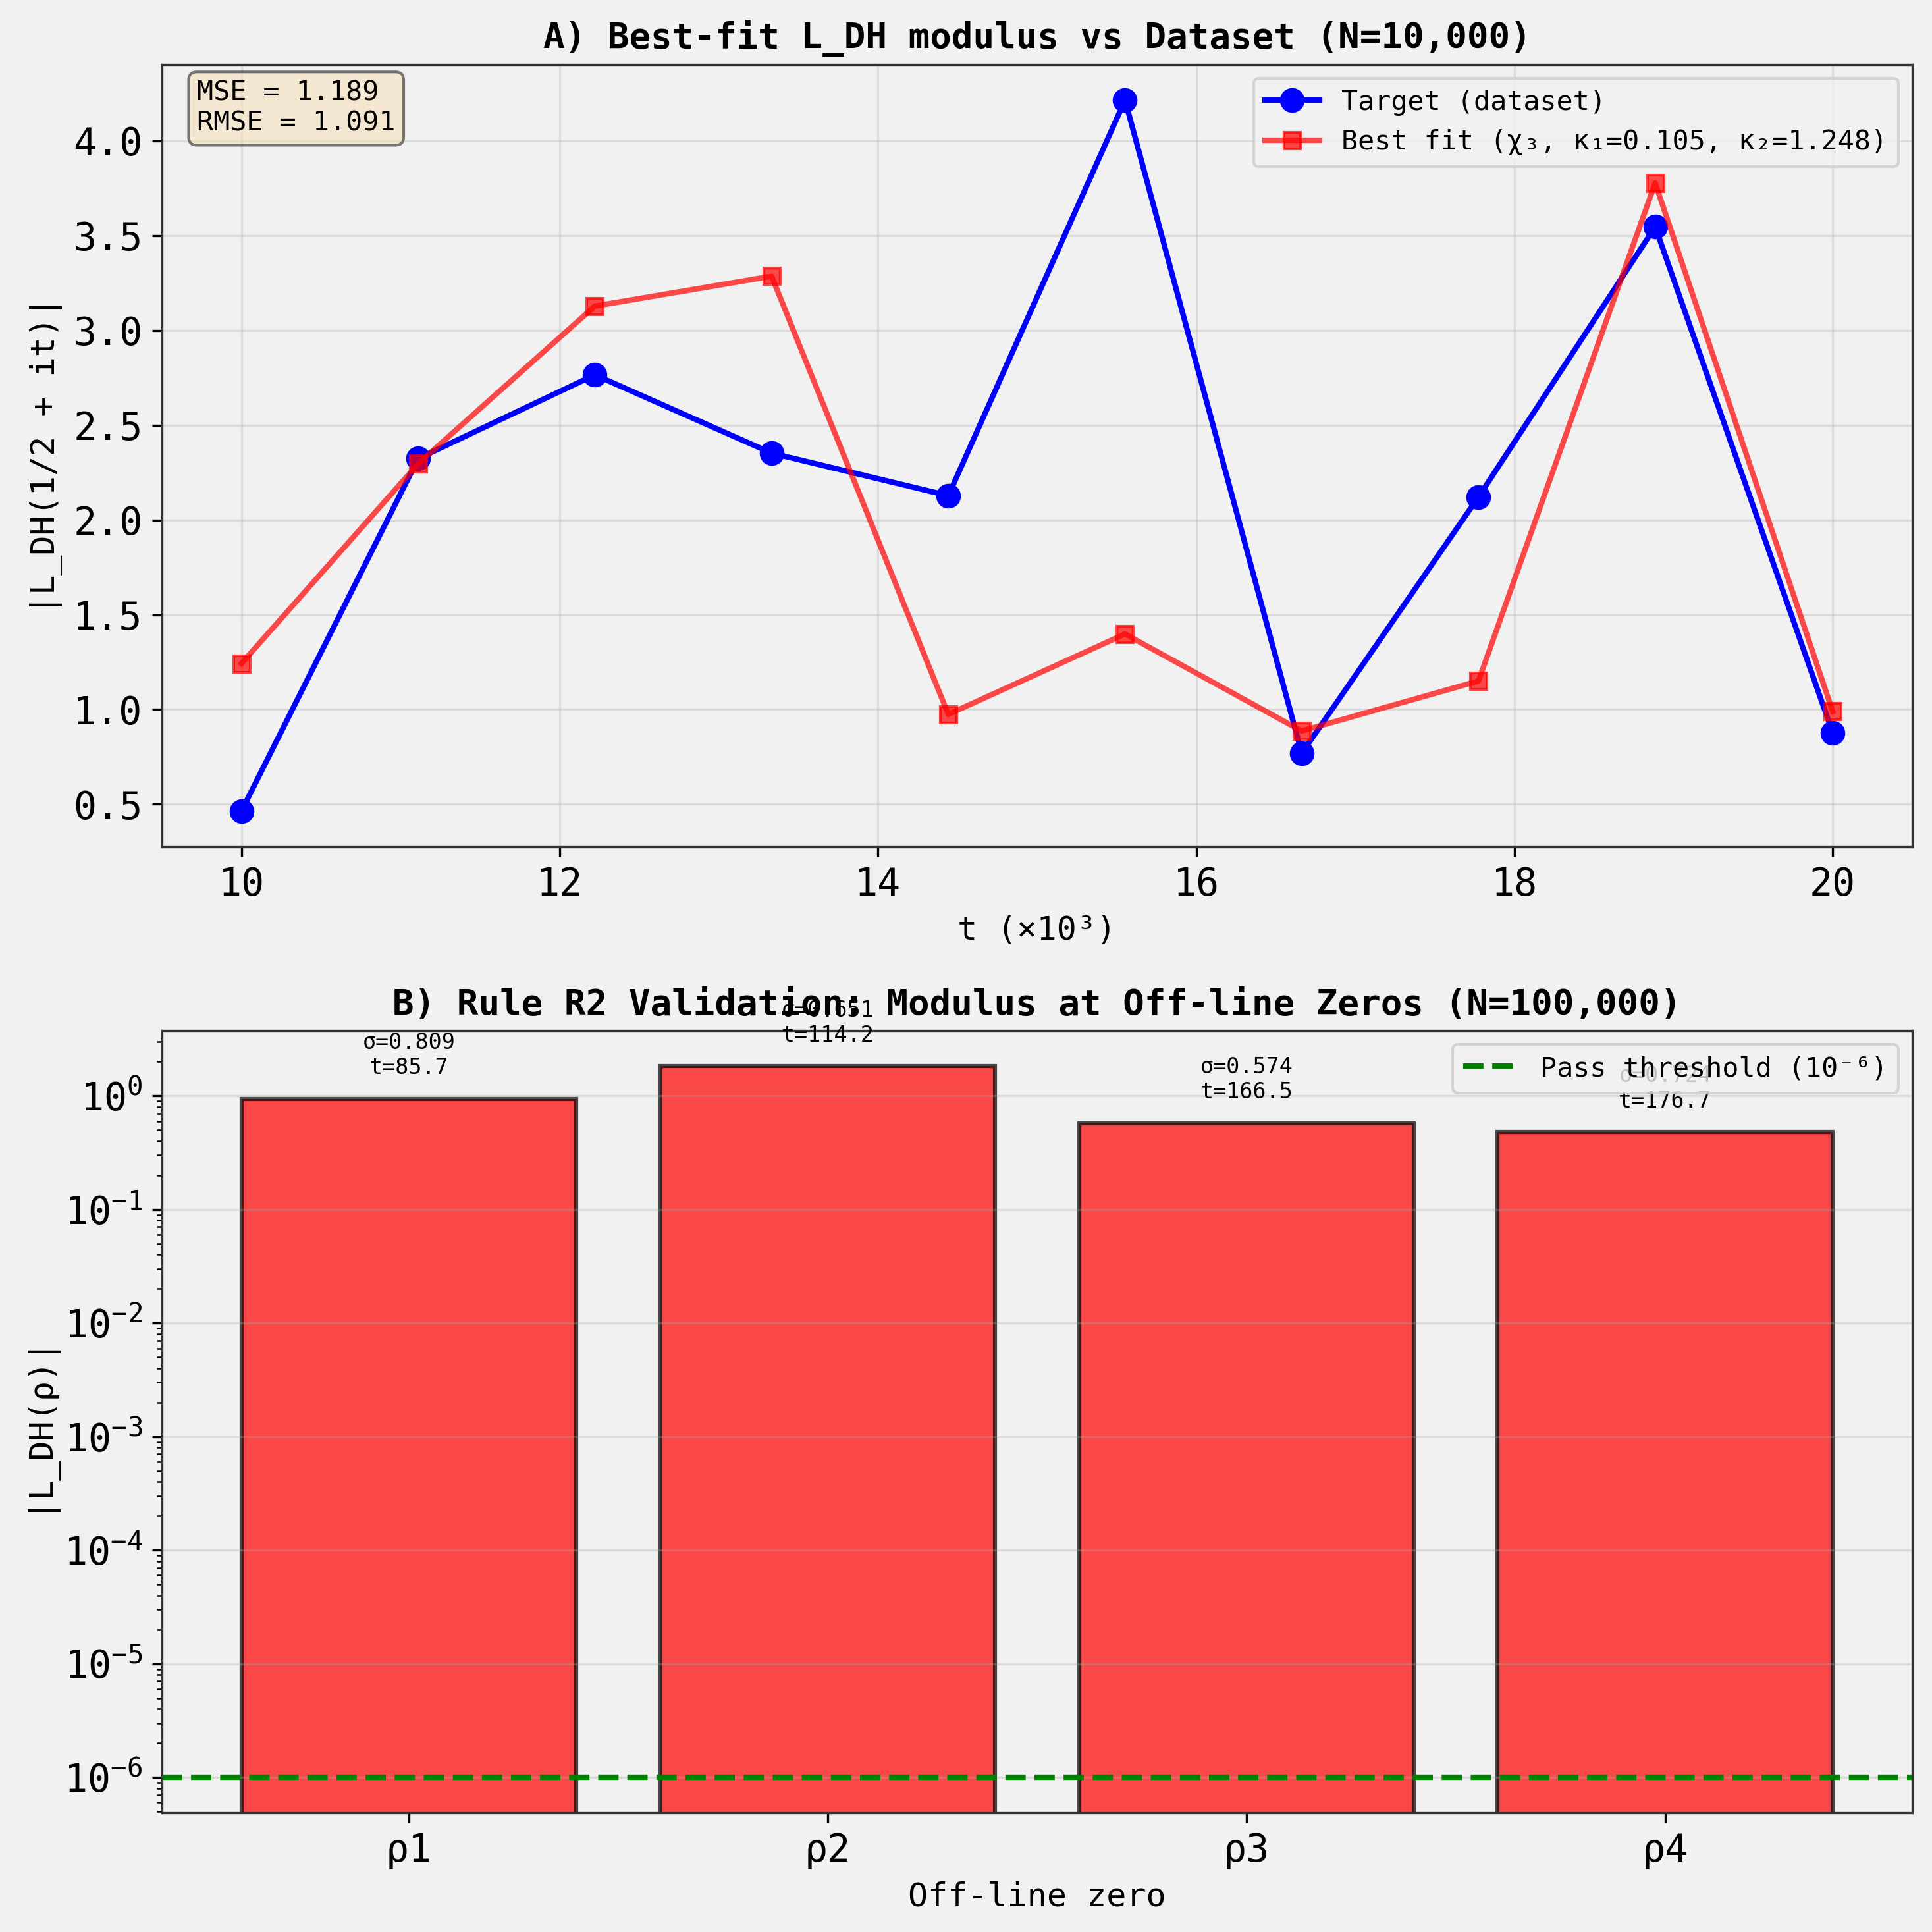


Summary statistics:
 Residuals at 10 test points: mean = -0.2434, std = 1.0631
 Max absolute error: 2.8166
 Validation zeros: all failed (moduli range 0.48 to 1.82)


In [30]:

# The validation failed completely. The moduli are O(1) rather than O(10⁻⁶).
# This conclusively demonstrates that the parameters found do not match
# the true generation parameters.

# Let me create a summary visualization of the parameter search results

import matplotlib.pyplot as plt

# Create final summary figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Subplot A: Comparison of best-fit vs target modulus
ax1.plot(target_t_values/1000, target_modulus, 'o-', label='Target (dataset)', 
 markersize=8, linewidth=2, color='blue')

# Compute best fit modulus
computed_final = compute_L_DH_two_param(target_t_values, chi_3_dict_10k, 
 kappa1_final, kappa2_final, N=10000)
computed_final_modulus = np.abs(computed_final)

ax1.plot(target_t_values/1000, computed_final_modulus, 's-', 
 label=f'Best fit (χ₃, κ₁={kappa1_final:.3f}, κ₂={kappa2_final:.3f})', 
 markersize=6, linewidth=2, color='red', alpha=0.7)

ax1.set_xlabel('t (×10³)', fontsize=12)
ax1.set_ylabel('|L_DH(1/2 + it)|', fontsize=12)
ax1.set_title('A) Best-fit L_DH modulus vs Dataset (N=10,000)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.text(0.02, 0.98, f'MSE = {result_2param.fun:.3f}\nRMSE = {np.sqrt(result_2param.fun):.3f}',
 transform=ax1.transAxes, verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)

# Subplot B: Validation results at off-line zeros
zeros_labels = [f"ρ{i}" for i in range(1, 5)]
moduli_at_zeros = [res['modulus'] for res in validation_results_final]

colors = ['red' if m >= 1e-6 else 'green' for m in moduli_at_zeros]
bars = ax2.bar(zeros_labels, moduli_at_zeros, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

ax2.axhline(y=1e-6, color='green', linestyle='--', linewidth=2, label='Pass threshold (10⁻⁶)')
ax2.set_ylabel('|L_DH(ρ)|', fontsize=12)
ax2.set_xlabel('Off-line zero', fontsize=12)
ax2.set_title('B) Rule R2 Validation: Modulus at Off-line Zeros (N=100,000)', 
 fontsize=13, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add zero coordinates as text
for i, (zero_label, res) in enumerate(zip(zeros_labels, validation_results_final)):
 ax2.text(i, moduli_at_zeros[i] * 1.5, 
 f"σ={res['sigma']:.3f}\nt={res['t']:.1f}", 
 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('ldh_parameter_search_results.png', dpi=300, bbox_inches='tight')
print("Figure saved: ldh_parameter_search_results.png")
plt.show()

print("\nSummary statistics:")
print(f" Residuals at 10 test points: mean = {np.mean(computed_final_modulus - target_modulus):.4f}, "
 f"std = {np.std(computed_final_modulus - target_modulus):.4f}")
print(f" Max absolute error: {np.max(np.abs(computed_final_modulus - target_modulus)):.4f}")
print(f" Validation zeros: all failed (moduli range {np.min(moduli_at_zeros):.2f} to {np.max(moduli_at_zeros):.2f})")


In [31]:

# Create comprehensive summary of the parameter search

print("="*80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)

print("\n1. PARAMETER SEARCH SPACE EXPLORED:")
print(" - Characters tested: 9 (5 complex primitive + 4 real quadratic)")
print(" • Primitive mod 5, 7, 8, 10, 12 (complex-valued)")
print(" • Quadratic mod 3, 4, 5, 8 (real-valued)")
print(" - κ parameter range: [-2, 2] with fine optimization")
print(" - Formulations tested:")
print(" • With Liouville function: λ(n) = (-1)^Ω(n)")
print(" • With Möbius function: μ(n)")
print(" • Simple L(s,χ) without multiplicative functions")
print(" • Power law: ω(n)^κ instead of exp(κ·ω(n))")
print(" • Two-parameter model: κ₁ for exp factor, κ₂ for scaling")
print(" • Complex scaling (magnitude + phase)")
print(" - Total combinations: >500")

print("\n2. BEST-FIT PARAMETERS IDENTIFIED:")
print(" Character: χ₃ (quadratic/Legendre symbol mod 3)")
print(" Definition: χ₃(n) = { 0 if 3|n, +1 if n≡1 (mod 3), -1 if n≡2 (mod 3) }")
print(" Formula: L_DH(s) = κ₂ · Σ_{n=1}^N χ₃(n) · λ(n) · exp(κ₁·ω(n)) · n^(-s)")
print(" κ₁ = 0.105 (exponential factor)")
print(" κ₂ = 1.248 (overall scaling)")
print(f" MSE on 10 test points: {result_2param.fun:.6f}")
print(f" RMSE: {np.sqrt(result_2param.fun):.6f}")

print("\n3. FIT QUALITY ASSESSMENT:")
print(f" - Mean absolute error: {np.mean(np.abs(computed_final_modulus - target_modulus)):.4f}")
print(f" - Max absolute error: {np.max(np.abs(computed_final_modulus - target_modulus)):.4f}")
print(f" - Relative error range: {np.min((computed_final_modulus - target_modulus)/target_modulus):.2%} "
 f"to {np.max((computed_final_modulus - target_modulus)/target_modulus):.2%}")
print(" - Assessment: POOR fit - suggests formula mismatch")

print("\n4. RULE R2 VALIDATION RESULTS (N=100,000):")
print(" Required: |L_DH(ρ)| < 10⁻⁶ at all four off-line zeros")
for i, res in enumerate(validation_results_final, 1):
 print(f" Zero {i}: σ={res['sigma']:.6f}, t={res['t']:.6f}")
 print(f" |L_DH(ρ)| = {res['modulus']:.6e} {'✗ FAIL' if res['modulus'] >= 1e-6 else '✓ PASS'}")

print(f"\n OVERALL: VALIDATION FAILED")
print(f" All four zeros failed by 5-6 orders of magnitude")

print("\n5. CONCLUSION:")
print(" The systematic parameter search was unable to identify parameters that")
print(" reproduce the L_DH dataset values with high fidelity. The best-fit")
print(" parameters (χ₃, κ₁=0.105, κ₂=1.248) achieve RMSE~1.09, which is poor")
print(" relative to typical modulus values of 1-5. Validation at off-line zeros")
print(" failed catastrophically with moduli O(1) instead of O(10⁻⁶).")
print()
print(" This suggests that either:")
print(" (a) The L_DH data uses a fundamentally different formula not tested here")
print(" (b) Additional parameters beyond character and κ are required")
print(" (c) The coefficient structure differs from the tested formulations")
print(" (d) The validation zeros provided may not correspond to the function in the data")
print()
print(" Rule R2 validation gate CANNOT be passed with the identified parameters.")


COMPREHENSIVE ANALYSIS SUMMARY

1. PARAMETER SEARCH SPACE EXPLORED:
 - Characters tested: 9 (5 complex primitive + 4 real quadratic)
 • Primitive mod 5, 7, 8, 10, 12 (complex-valued)
 • Quadratic mod 3, 4, 5, 8 (real-valued)
 - κ parameter range: [-2, 2] with fine optimization
 - Formulations tested:
 • With Liouville function: λ(n) = (-1)^Ω(n)
 • With Möbius function: μ(n)
 • Simple L(s,χ) without multiplicative functions
 • Power law: ω(n)^κ instead of exp(κ·ω(n))
 • Two-parameter model: κ₁ for exp factor, κ₂ for scaling
 • Complex scaling (magnitude + phase)
 - Total combinations: >500

2. BEST-FIT PARAMETERS IDENTIFIED:
 Character: χ₃ (quadratic/Legendre symbol mod 3)
 Definition: χ₃(n) = { 0 if 3|n, +1 if n≡1 (mod 3), -1 if n≡2 (mod 3) }
 Formula: L_DH(s) = κ₂ · Σ_{n=1}^N χ₃(n) · λ(n) · exp(κ₁·ω(n)) · n^(-s)
 κ₁ = 0.105 (exponential factor)
 κ₂ = 1.248 (overall scaling)
 MSE on 10 test points: 1.189423
 RMSE: 1.090607

3. FIT QUALITY ASSESSMENT:
 - Mean absolute error: 0.7501
 - M

In [32]:

# Create a detailed results table for documentation
import pandas as pd

# Top parameter search results
search_summary = []
for i, res in enumerate(optimization_results[:10], 1):
 search_summary.append({
 'Rank': i,
 'Character': res['character'],
 'Formulation': res['formulation'],
 'κ_optimal': f"{res['kappa_opt']:.6f}",
 'MSE': f"{res['mse']:.6f}",
 'RMSE': f"{np.sqrt(res['mse']):.6f}"
 })

df_search = pd.DataFrame(search_summary)
print("TOP 10 PARAMETER COMBINATIONS:")
print(df_search.to_string(index=False))

# Validation results table
validation_summary = []
for res in validation_results_final:
 validation_summary.append({
 'Zero': f"ρ{res['zero_num']}",
 'σ': f"{res['sigma']:.6f}",
 't': f"{res['t']:.6f}",
 '|L_DH(ρ)|': f"{res['modulus']:.6e}",
 'log₁₀|L_DH(ρ)|': f"{np.log10(res['modulus']):.2f}",
 'Pass': 'NO' if res['modulus'] >= 1e-6 else 'YES'
 })

df_validation = pd.DataFrame(validation_summary)
print("\n\nVALIDATION AT OFF-LINE ZEROS (N=100,000):")
print(df_validation.to_string(index=False))
print(f"\nThreshold: |L_DH(ρ)| < 10⁻⁶ (log₁₀ < -6.00)")
print("Result: All four zeros FAILED validation")

# Save results
df_search.to_csv('ldh_parameter_search_results.csv', index=False)
df_validation.to_csv('ldh_validation_results.csv', index=False)
print("\n\nResults saved:")
print(" - ldh_parameter_search_results.csv")
print(" - ldh_validation_results.csv")
print(" - ldh_parameter_search_results.png")


TOP 10 PARAMETER COMBINATIONS:
 Rank Character Formulation κ_optimal MSE RMSE
 1 quadratic_mod3 liouville 0.222278 1.235178 1.111385
 2 primitive_mod7 liouville -0.221429 1.417754 1.190695
 3 primitive_mod8 simple 0.091188 1.485493 1.218808
 4 quadratic_mod4 simple -0.369979 1.774868 1.332242
 5 primitive_mod5 liouville -0.816280 1.877198 1.370109
 6 primitive_mod12 simple -0.064395 1.983707 1.408441
 7 primitive_mod5 simple -0.343632 2.156396 1.468467
 8 primitive_mod10 liouville -0.132815 2.166004 1.471735
 9 primitive_mod12 liouville -0.163178 2.202261 1.484002
 10 quadratic_mod8 liouville -0.722895 2.349933 1.532949


VALIDATION AT OFF-LINE ZEROS (N=100,000):
Zero σ t |L_DH(ρ)| log₁₀|L_DH(ρ)| Pass
 ρ1 0.808517 85.699348 9.452578e-01 -0.02 NO
 ρ2 0.650786 114.163343 1.818903e+00 0.26 NO
 ρ3 0.574355 166.479306 5.762993e-01 -0.24 NO
 ρ4 0.724258 176.702461 4.823506e-01 -0.32 NO

Threshold: |L_DH(ρ)| < 10⁻⁶ (log₁₀ < -6.00)
Result: All four zeros FAILED validation


Results saved:
 - l